#### SPA6330: Artificial Intelligence and Machine Learning
#### MO: Dr Linda Cremonesi

# Final Project - Predicting House Prices in England

<hr style="border:2px solid gray">

## Problem formulation:

The aim of this report is to predict the median house price for different areas in England using a linear regression model. Over the course of the last few years, house prices have been very volatile. From 2024 to 2025, there was a 4.9% increase in average house prices, and in 2021, prices fluctuated by nearly 10% within a single month [2]. Therefore predicting these house prices is quite useful for potential buyers, investors, or even policy makers to give a clear baseline estimate of house prices in a given area given how dynamic they can be. 

The dataset used in this project, HousingEngland.csv [1], contains approximately 33,000 entries, each corresponding to a specific area. Each entry includes nine features: a unique geography code, geographic coordinates (latitude and longitude), population size and density, number of households, number of bedrooms and total rooms, and the average income of the area. The target variable is the median house price.

As this is a regression problem, a linear regression model will be used as they are effective at highlighting any clear trends in continuous data and to provide results that are more easily interpretable compared to more complex models. Furthermore, both ridge and lasso regularisation techniques will be used and evaluated in order to better understand which features are important as well as to prevent overfitting.

## Data preparation and feature engineering:

In [1]:
#IMPORTS
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.patches as mpatches
from matplotlib import colors
from matplotlib.lines import Line2D
import pandas.plotting as pdp
import pandas.plotting as pd_plot

from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model 
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV, LassoCV 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder 
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from collections import Counter

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning) #suppresses convergence warnings, simply for formatting purposes

In [2]:
#Set up feature Data frames and remove problematic instances
features = pd.read_csv('HousingEngland.csv') #reads the file into the variable features
print('There are {} NaN values in this spreadsheet'.format(features.isna().sum().sum())) #counts the number of NaN values in the data set
print('There are {} instances with a value of zero or 1000000 in one of their features'.format((features == 0.0).sum().sum()+(features == 1000000).sum().sum()))#counts the number of cells with a value of 0
features=features[(features != 0).all(axis=1)] #removes all instances that have a cell that equals 0
print('There are {} instances with a value of zero or 1000000 in one of their features after dropping'.format((features == 0.0).sum().sum())) #checks for cells that contain a 0 again
features=features[(features['median house price'] != 1000000)] #removes all instances that have a cell that equals 1000000 (the maximum allowed house price)
features2= features.drop(columns=['median house price', 'geography code']) #drops the target and unnecessary columns from features data frame

#Engineering new features 
features2['Average Bedrooms']=features2['total rooms']/features2['households']
features2['Average Rooms']=features2['total bedrooms']/features2['households']

#set up targets
targets = features['median house price']


There are 0 NaN values in this spreadsheet
There are 716 instances with a value of zero or 1000000 in one of their features
There are 0 instances with a value of zero or 1000000 in one of their features after dropping


To begin, all features with NaN cells or cells with maximised/minimised values need to be removed. This is in order prevent erroneous instances from training model. 

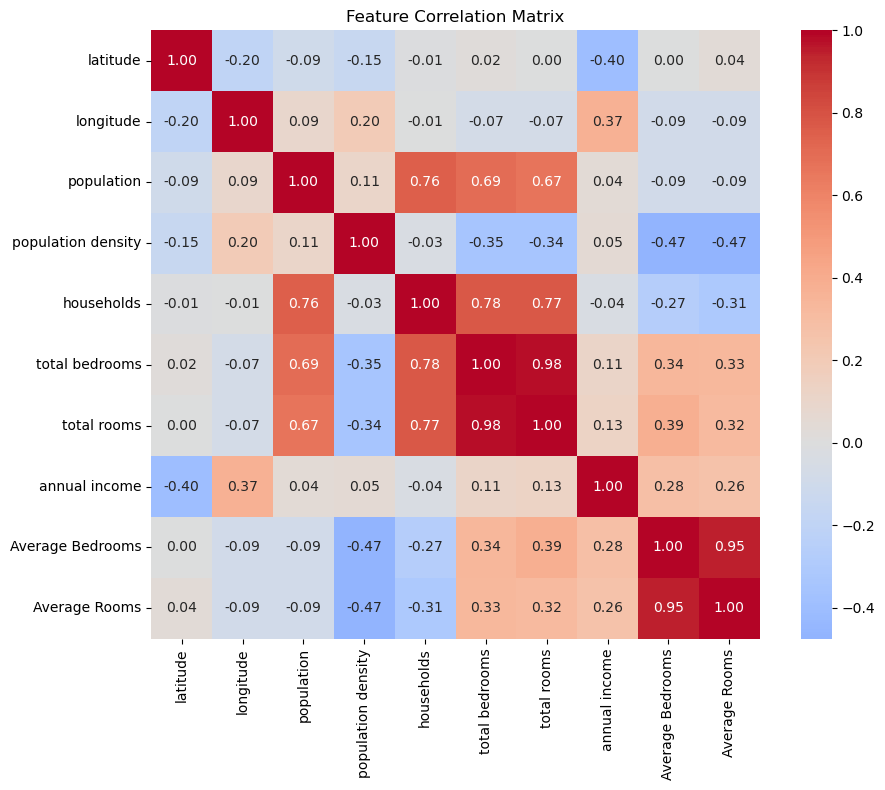

In [3]:
corr_matrix = features2.corr(numeric_only=True)  # Avoids issues with non-numeric columns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

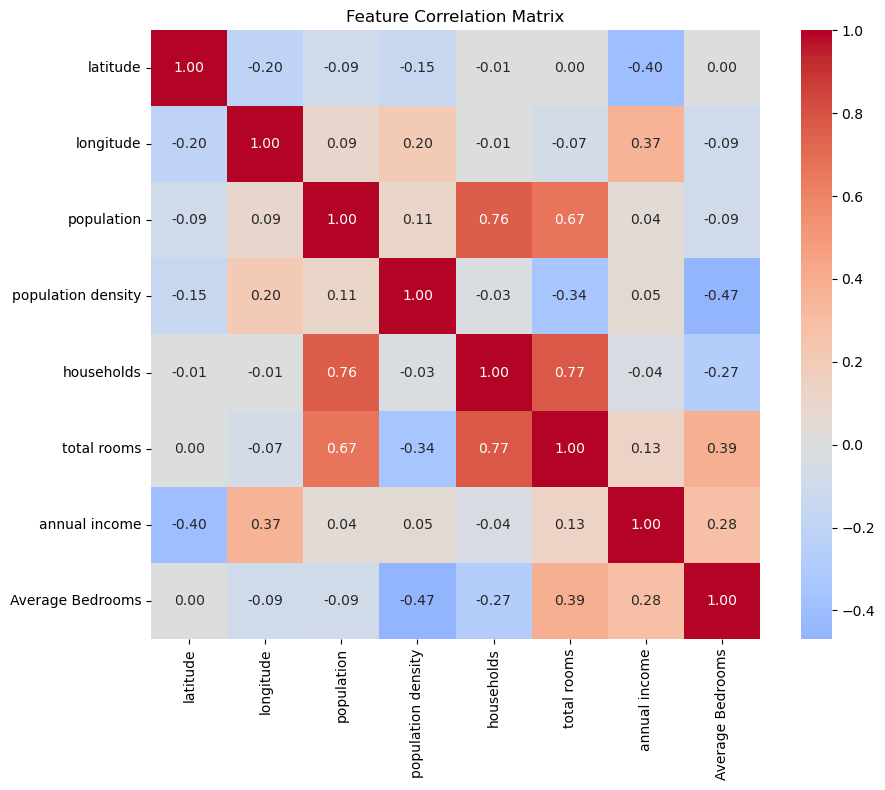

In [4]:
features2= features2.drop(columns=['Average Rooms', 'total bedrooms'])
corr_matrix = features2.corr(numeric_only=True)  # Avoids issues with non-numeric columns

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

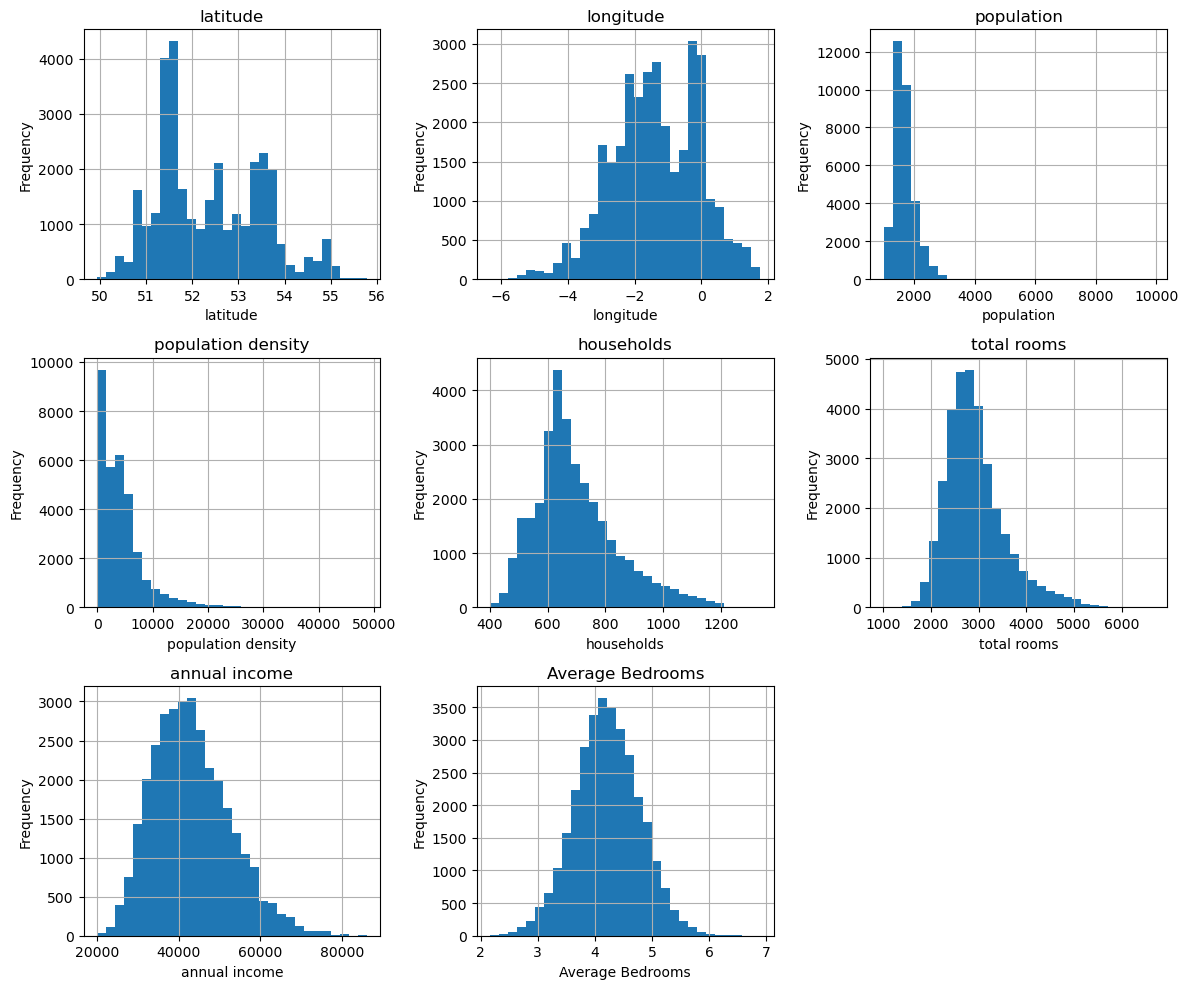

In [5]:
# Create histograms
axes = features2.hist(figsize=(12, 10), bins=30)

# Loop through each subplot to set labels
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title())     # Set x-label to the feature name
    ax.set_ylabel("Frequency")        # Set consistent y-label

plt.tight_layout()
plt.show()

In [6]:
#Statistical Information about the current feature set
features2.describe()

,latitude,longitude,population,population density,households,total rooms,annual income,Average Bedrooms
count,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000,32368.000000
mean,52.367697,-1.355876,1672.440651,4197.480907,698.552274,2926.943123,43210.235418,4.220997
std,1.131019,1.303542,343.101396,4090.608251,142.964323,634.431439,9565.800336,0.571090
min,49.935546,-6.314363,996.000000,2.300000,402.000000,1013.000000,20000.000000,2.168067
25%,51.474211,-2.228759,1445.000000,1184.450000,605.000000,2500.000000,36200.000000,3.841014
50%,52.197717,-1.393982,1608.000000,3448.600000,669.000000,2820.000000,42300.000000,4.211689
75%,53.379330,-0.264004,1834.000000,5683.125000,772.000000,3217.000000,49300.000000,4.600906
max,55.784110,1.757414,9899.000000,48672.800000,1336.000000,6666.000000,86100.000000,6.897059


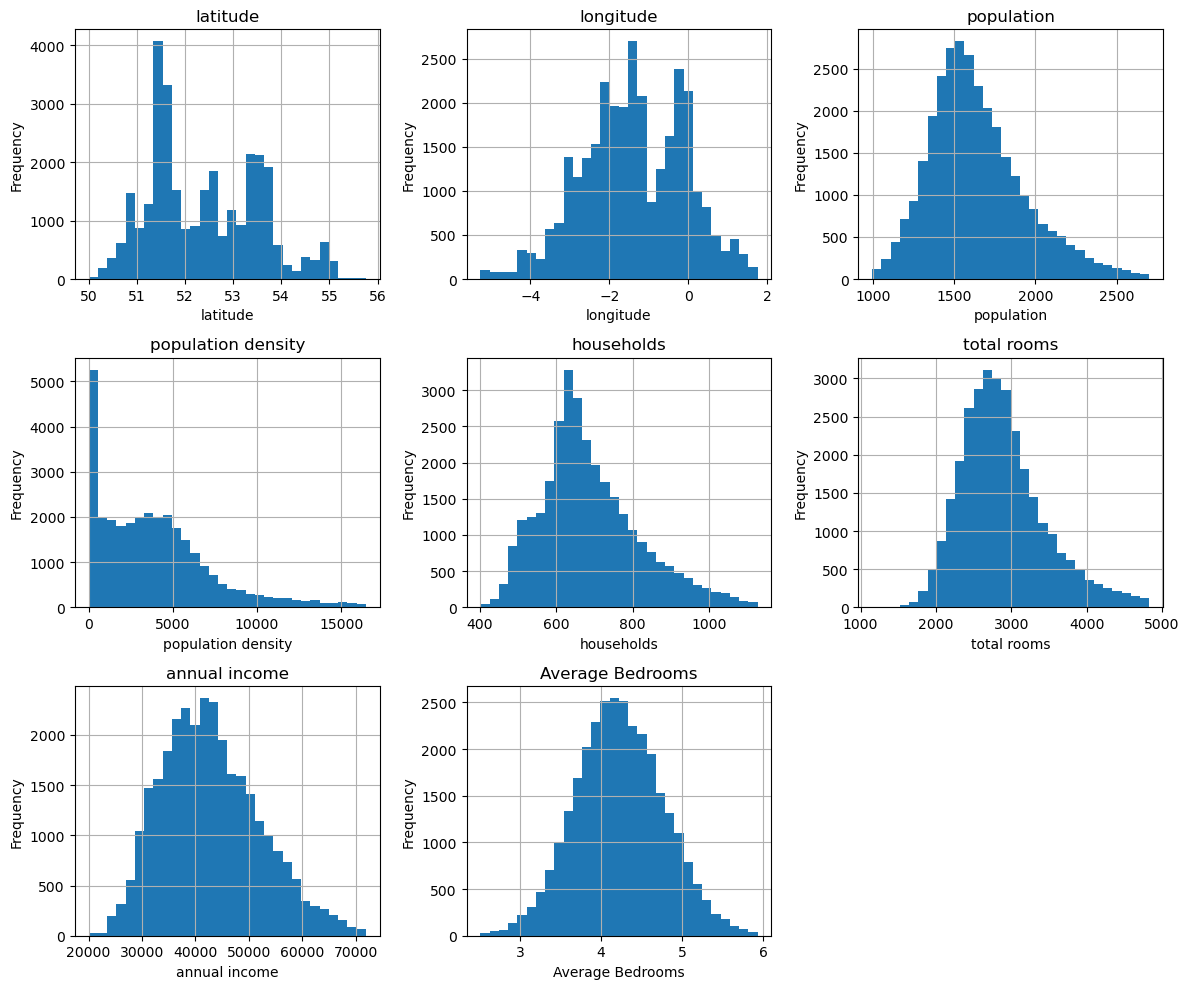

In [7]:
#Remove instances that contain cells that are three standard deviations away from their respective means
z_scores = np.abs(features2.apply(stats.zscore))
final_features = features2[(z_scores < 3).all(axis=1)]

#plot each histogram again to show the distribution 
axes = final_features.hist(figsize=(12, 10), bins=30)

# Loop through each subplot to set labels
for ax in axes.flatten():
    ax.set_xlabel(ax.get_title())     # Set x-label to the feature name
    ax.set_ylabel("Frequency")        # Set consistent y-label


plt.tight_layout()
plt.show()

In [8]:
#again showing Statistical Information about the current feature set
final_features.describe()

,latitude,longitude,population,population density,households,total rooms,annual income,Average Bedrooms
count,30528.000000,30528.000000,30528.000000,30528.000000,30528.000000,30528.000000,30528.000000,30528.000000
mean,52.393808,-1.376749,1642.204009,3883.493429,688.748559,2891.996430,42862.044680,4.230112
std,1.133775,1.292757,295.437137,3291.787809,129.924066,562.236919,9217.345029,0.543837
min,50.002141,-5.265967,996.000000,2.300000,402.000000,1153.000000,20000.000000,2.507788
25%,51.476973,-2.242156,1438.000000,1201.850000,604.000000,2501.000000,36000.000000,3.857562
50%,52.261360,-1.429059,1595.000000,3410.500000,665.000000,2811.000000,42000.000000,4.215436
75%,53.394223,-0.305352,1804.000000,5547.325000,761.000000,3187.000000,48900.000000,4.595761
max,55.757065,1.757414,2701.000000,16463.700000,1127.000000,4830.000000,71900.000000,5.933126


In [9]:
targets = targets[final_features.index] #matches index with final features
targets.columns=['median house price']#renames the column of targets
#Resets the numbering of the data frame indexes
final_features = final_features.reset_index(drop=True)
targets = targets.reset_index(drop=True)

In [10]:
#Splits the data frames into train and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(final_features,targets,random_state=42)
ytrain.columns=['median house price']

## Model selection and training: 

In [11]:
#Creates the linear regression model, with a standard scaler to ensure the features are scaled appropriately; train the model and creates predictions  
Linear_model=make_pipeline(StandardScaler(), LinearRegression()) 
Linear_model.fit(Xtrain,ytrain) 
y_pred_Linear=Linear_model.predict(Xtest)
#Same but for a linear model utilising Ridge Regression
Ridge_model=make_pipeline(StandardScaler(), Ridge(alpha = 1.0)) 
Ridge_model.fit(Xtrain,ytrain)
y_pred_Ridge=Ridge_model.predict(Xtest)
#Same but for a linear model utilising LASSO Regression
Lasso_model=make_pipeline(StandardScaler(), Lasso(alpha = 0.1)) 
Lasso_model.fit(Xtrain,ytrain)
y_pred_Lasso=Lasso_model.predict(Xtest)

In [12]:
#Prints the R2, MSE and RMSE scores for each model
print('-----------------------')
print('Linear Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Linear)))
print('MSE:{:.3f}'.format(mean_squared_error(ytest, y_pred_Linear)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Linear))))
print('-----------------------')
print('Ridge Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Ridge)))
print('MSE:{:.3f}'.format(mean_squared_error(ytest, y_pred_Ridge)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Ridge))))
print('-----------------------')
print('Lasso Regression')
print('R²:{:.5f}'.format(r2_score(ytest, y_pred_Lasso)))
print('MSE:{:.3f}'.format(mean_squared_error(ytest, y_pred_Lasso)))
print('RMSE:{:.3f}'.format(np.sqrt(mean_squared_error(ytest, y_pred_Lasso))))
print('-----------------------')

-----------------------
Linear Regression
R²:0.67893
MSE:8424601445.476
RMSE:91785.628
-----------------------
Ridge Regression
R²:0.67893
MSE:8424818231.878
RMSE:91786.809
-----------------------
Lasso Regression
R²:0.67893
MSE:8424608554.319
RMSE:91785.666
-----------------------


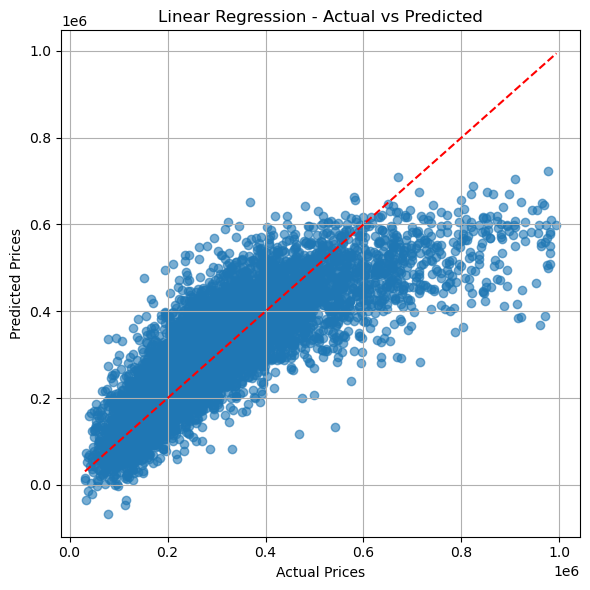

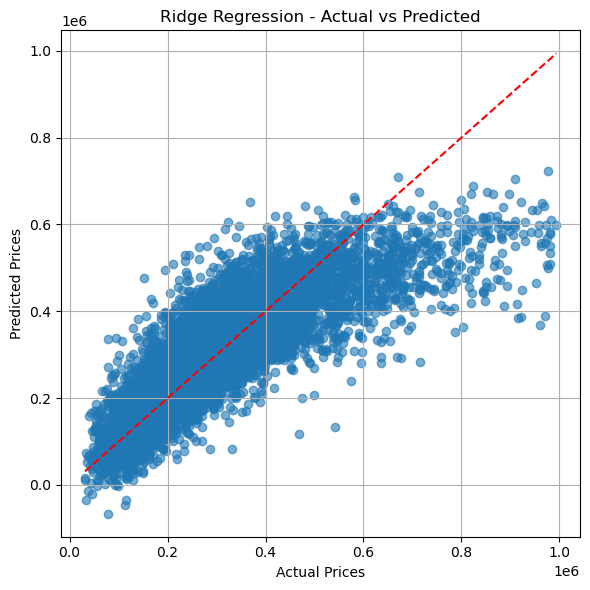

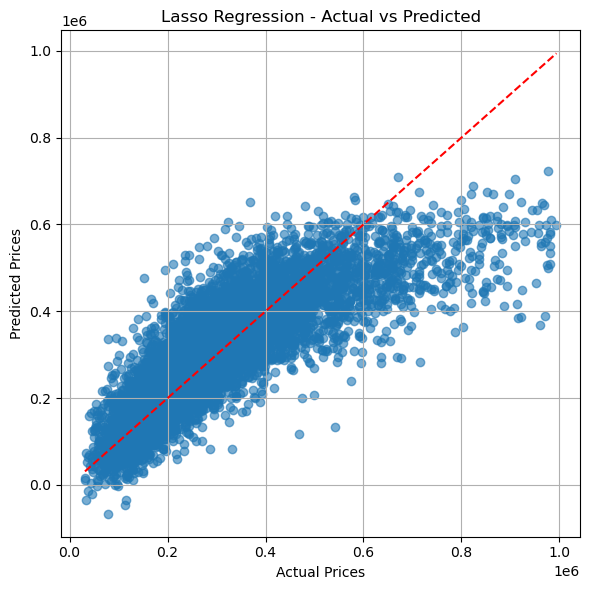

In [13]:
def plot_predicted_vs_actual(ytest, y_pred, title):
    "A function that shows what a model predicts vs the actual value. The parameters it takes in are the predicted values, the actual values, and a string for the title of the graph"
    plt.figure(figsize=(6, 6))
    plt.scatter(ytest, y_pred, alpha=0.6)
    plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')
    plt.title(f'{title} - Actual vs Predicted')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
#Plots the actual vs predicted values for each model
plot_predicted_vs_actual(ytest, y_pred_Linear, "Linear Regression")
plot_predicted_vs_actual(ytest, y_pred_Ridge, "Ridge Regression")
plot_predicted_vs_actual(ytest, y_pred_Lasso, "Lasso Regression")

## Model evaluation:

In [14]:
#Creates a scorer for cross validation based on Mean Squared Error
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Set up cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression R2 and MSE
lin_cv_r2 = cross_val_score(Linear_model, final_features, targets, cv=cv, scoring='r2')
lin_cv_mse = cross_val_score(Linear_model, final_features, targets, cv=cv, scoring=mse_scorer)

# Ridge R2 and MSE
ridge_cv_r2 = cross_val_score(Ridge_model, final_features, targets, cv=cv, scoring='r2')
ridge_cv_mse = cross_val_score(Ridge_model, final_features, targets, cv=cv, scoring=mse_scorer)

# Lasso R2 and MSE (causes multiple convergence warnings)
lasso_cv_r2 = cross_val_score(Lasso_model, final_features, targets, cv=cv, scoring='r2')
lasso_cv_mse = cross_val_score(Lasso_model, final_features, targets, cv=cv, scoring=mse_scorer)

print("Linear Regression: Mean R² =", lin_cv_r2.mean(), " | RMSE =", np.sqrt(-lin_cv_mse.mean()))
print("Ridge Regression:  Mean R² =", ridge_cv_r2.mean(), " | RMSE =", np.sqrt(-ridge_cv_mse.mean()))
print("Lasso Regression:  Mean R² =", lasso_cv_r2.mean(), " | RMSE =", np.sqrt(-lasso_cv_mse.mean()))

Linear Regression: Mean R² = 0.6702672998329067  | RMSE = 92445.3598055099
Ridge Regression:  Mean R² = 0.6702677852556664  | RMSE = 92445.30507813967
Lasso Regression:  Mean R² = 0.6702673081318011  | RMSE = 92445.35913477057


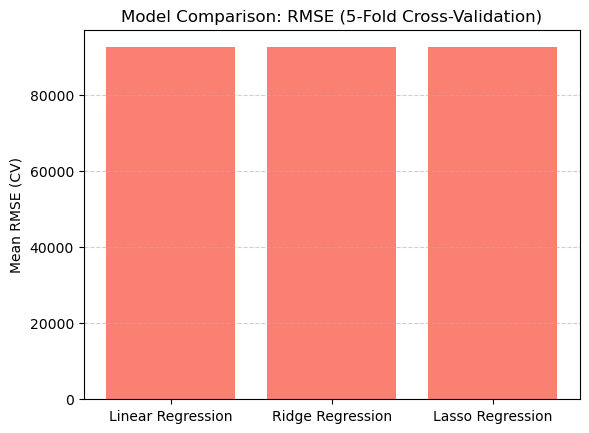

In [15]:
#Creating a bar chart to show the difference in RMSE between models
models = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']
mean_rmse = [np.sqrt(-lin_cv_mse.mean()), np.sqrt(-ridge_cv_mse.mean()), np.sqrt(-lasso_cv_mse.mean())]

plt.bar(models, mean_rmse, capsize=5, color='salmon')
plt.ylabel('Mean RMSE (CV)')
plt.title('Model Comparison: RMSE (5-Fold Cross-Validation)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [16]:
def modified_mape(y_true, y_pred):
    "Calculates the percentage difference between the true value and the predicted value"
    return np.mean(np.abs(y_true - y_pred) / np.maximum(y_true, 1)) * 100  # Avoid division by zero

#creates a scorer using the function above
mape_scorer = make_scorer(modified_mape, greater_is_better=False)

#calculates the MAPE for each model and prints the results
scores_lin = cross_validate(Linear_model, final_features, targets, cv=cv, scoring=mape_scorer, return_train_score=True)
scores_ridge = cross_validate(Ridge_model, final_features, targets, cv=cv, scoring=mape_scorer, return_train_score=True)
scores_lasso = cross_validate(Lasso_model, final_features, targets, cv=cv, scoring=mape_scorer, return_train_score=True)
print("MAPE Linear Score: {:.4f}%".format(-np.mean(scores_lin['test_score'])))
print("MAPE Ridge Score: {:.4f}%".format(-np.mean(scores_ridge['test_score'])))
print("MAPE Lasso Score: {:.4f}%".format(-np.mean(scores_lasso['test_score'])))

MAPE Linear Score: 25.0690%
MAPE Ridge Score: 25.0682%
MAPE Lasso Score: 25.0690%


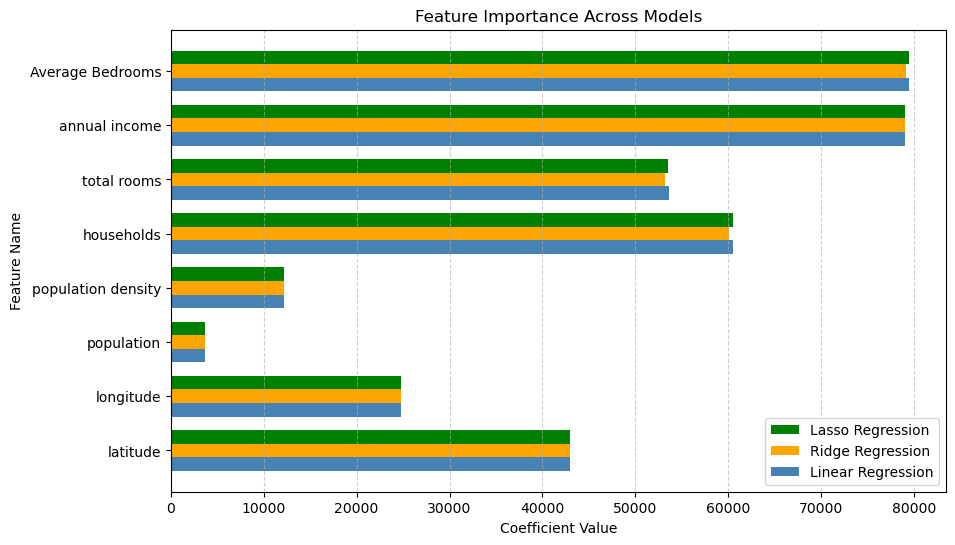

In [17]:
#Finds the magnitude of the importance of each feature for each model
coeffs_Linear = np.abs(Linear_model.named_steps['linearregression'].coef_)
coeffs_Ridge = np.abs(Ridge_model.named_steps['ridge'].coef_)
coeffs_Lasso = np.abs(Lasso_model.named_steps['lasso'].coef_)

#Creates a bar chart based on the importance of each feature

n_features = len(final_features.columns)
index = np.arange(n_features)

bar_width = 0.25

plt.figure(figsize=(10, 6))
#horizontal bar chat chosen for easier feature readability 
plt.barh(index + bar_width, coeffs_Lasso, height=bar_width, label='Lasso Regression', color='green')
plt.barh(index, coeffs_Ridge, height=bar_width, label='Ridge Regression', color='orange')
plt.barh(index - bar_width, coeffs_Linear, height=bar_width, label='Linear Regression', color='steelblue')

plt.yticks(index, final_features)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Name')
plt.title('Feature Importance Across Models')
plt.legend()

plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

## Model tuning: 

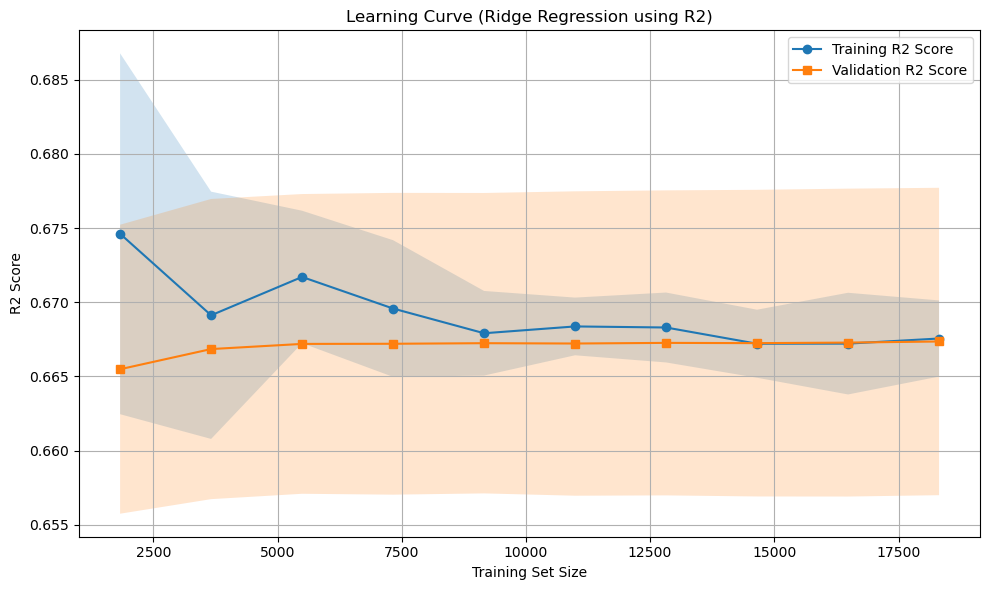

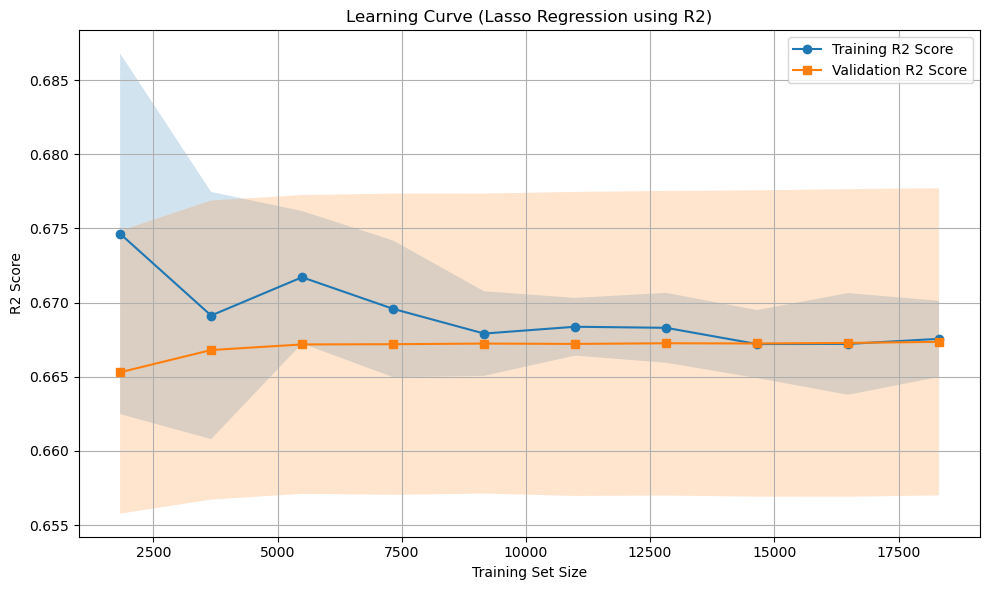

In [18]:
def learning_curve_maker(model, metric, title, yaxis):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X=Xtrain,
        y=ytrain,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring=metric,  
        shuffle=True,
        random_state=42
    )
    
    # Calculate mean and std for plotting
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, label=('Training {}'.format(yaxis)), marker='o')
    plt.plot(train_sizes, val_scores_mean, label=('Validation {}'.format(yaxis)), marker='s')
    plt.fill_between(train_sizes,
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.2)
    plt.fill_between(train_sizes,
                     val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std,
                     alpha=0.2)
    
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel(yaxis)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
Ridge_curve=learning_curve_maker(Ridge_model, 'r2', "Learning Curve (Ridge Regression using R2)", 'R2 Score')
Lasso_curve=learning_curve_maker(Lasso_model, 'r2', "Learning Curve (Lasso Regression using R2)",'R2 Score')

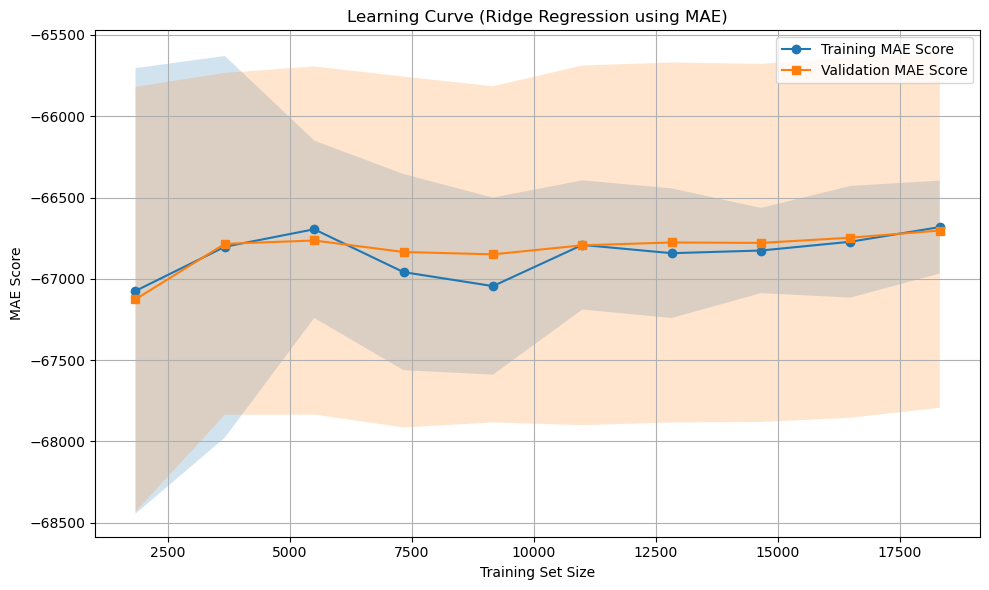

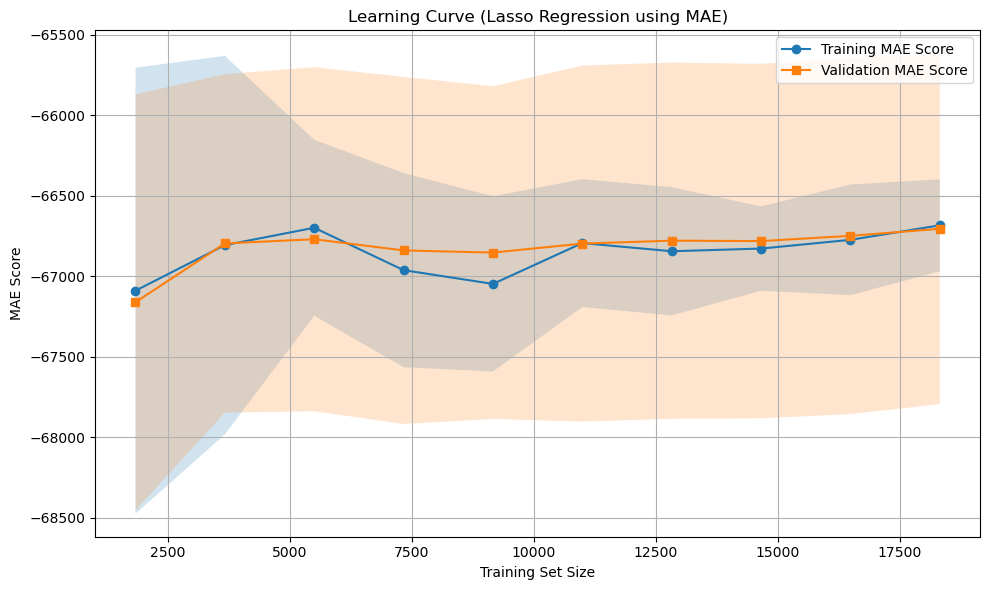

In [19]:
ridge_mae_curve=learning_curve_maker(Ridge_model, 'neg_mean_absolute_error', "Learning Curve (Ridge Regression using MAE)","MAE Score")
lasso_mae_curve=learning_curve_maker(Lasso_model, 'neg_mean_absolute_error', "Learning Curve (Lasso Regression using MAE)","MAE Score")

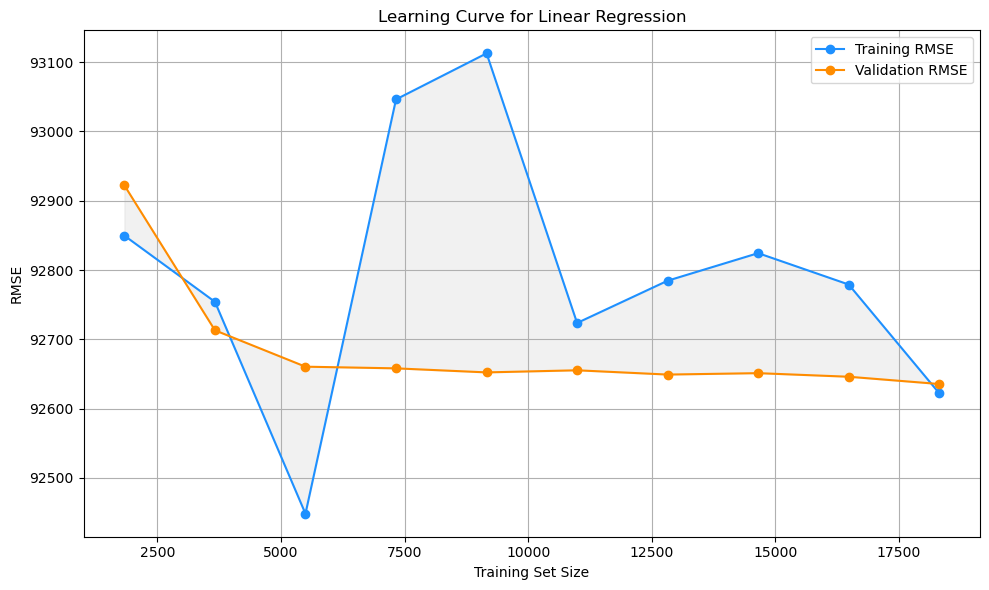

In [20]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(Lasso_model, Xtrain, ytrain, cv=5, scoring='neg_root_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10),shuffle=True,random_state=42)

# Calculate means and standard deviations
train_scores_mean = -train_scores.mean(axis=1)
val_scores_mean = -val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Training RMSE', color='dodgerblue')
plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation RMSE', color='darkorange')
plt.fill_between(train_sizes, train_scores_mean, val_scores_mean, color='lightgray', alpha=0.3)
plt.xlabel('Training Set Size')
plt.ylabel('RMSE')
plt.title('Learning Curve for Linear Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Best Ridge alpha: 1.0
Best Lasso alpha: 1.0


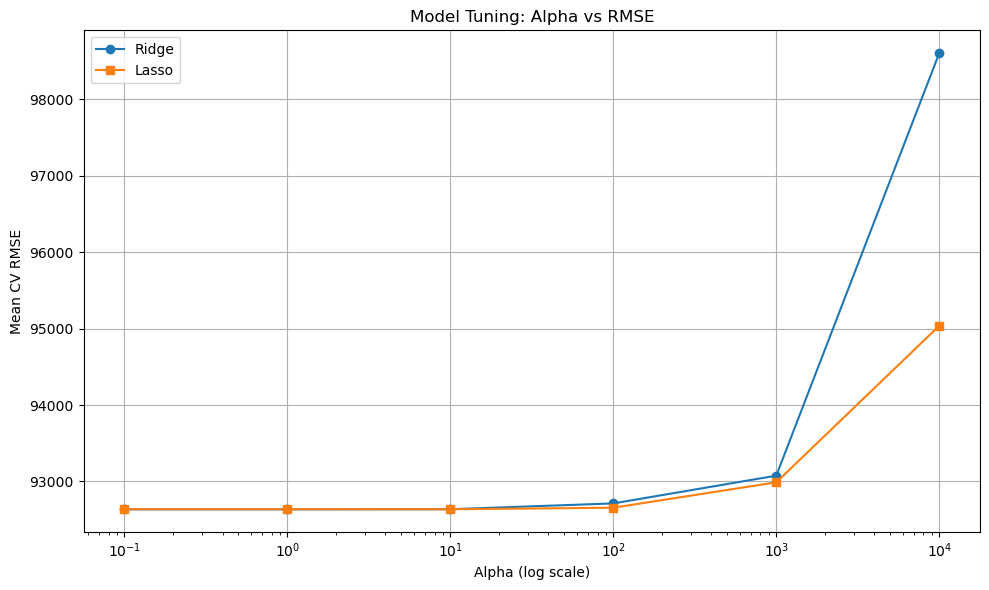

In [21]:
alphas=np.logspace(-1, 4, 6)
ridge_grid = GridSearchCV(make_pipeline(StandardScaler(), Ridge()), 
                          param_grid={'ridge__alpha': alphas}, 
                          scoring='neg_root_mean_squared_error', cv=5)
ridge_grid.fit(Xtrain, ytrain)

# Grid Search Lasso
lasso_grid = GridSearchCV(make_pipeline(StandardScaler(), Lasso(max_iter=1_000_000)), 
                          param_grid={'lasso__alpha': alphas}, 
                          scoring='neg_root_mean_squared_error', cv=5)
lasso_grid.fit(Xtrain, ytrain)

print("Best Ridge alpha:", ridge_grid.best_params_['ridge__alpha'])
print("Best Lasso alpha:", lasso_grid.best_params_['lasso__alpha'])

plt.figure(figsize=(10, 6))
plt.semilogx(alphas, -ridge_grid.cv_results_['mean_test_score'], label='Ridge', marker='o')
plt.semilogx(alphas, -lasso_grid.cv_results_['mean_test_score'], label='Lasso', marker='s')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV RMSE')
plt.title('Model Tuning: Alpha vs RMSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
#ridge_params = {'alpha': [0.1, 1, 10, 100]}
#ridge_grid = GridSearchCV(Ridge(), ridge_params, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
#ridge_grid.fit(Xtrain, ytrain)

#print("Best Ridge Alpha:", ridge_grid.best_params_)
#print("Best Ridge Score:", -ridge_grid.best_score_)

#Lasso_params = {'alpha': [0.1, 1, 10, 100]}
#Lasso_grid = GridSearchCV(Lasso(), Lasso_params, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
#Lasso_grid.fit(Xtrain, ytrain)

#print("Best Lasso Alpha:", Lasso_grid.best_params_)
#print("Best Lasso Score:", -Lasso_grid.best_score_)

In [23]:
#lasso_cv = LassoCV(alphas=np.logspace(-1, 4, 6), max_iter=10000000, cv=5)
#lasso_cv.fit(Xtrain, ytrain)

#best_alpha_lasso = lasso_cv.alpha_
#print(f"The best alpha for Lasso is: {best_alpha_lasso}")

In [24]:
#ridge_cv = RidgeCV(alphas=np.logspace(-1, 4, 6), cv=5)
#ridge_cv.fit(Xtrain, ytrain)

#best_alpha_ridge = ridge_cv.alpha_
#print(f"The best alpha for Ridge is: {best_alpha_ridge}")


In [25]:
#Created new piped model for best alpha searching and trained it
Ridge_piped_new = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-1, 4, 6), cv=5))
Ridge_piped_new.fit(Xtrain, ytrain)

best_alpha_rid = Ridge_piped_new.named_steps['ridgecv'].alpha_
print("Best alpha:", best_alpha_rid)

Best alpha: 1.0


In [26]:
#Created new piped model for best alpha searching and trained i
Lasso_piped_new = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-1, 4, 6), cv=5, max_iter=10000))
Lasso_piped_new.fit(Xtrain, ytrain)

best_alpha_las = Lasso_piped_new.named_steps['lassocv'].alpha_
print("Best alpha:{:.1f}".format(best_alpha_las))

Best alpha:0.1


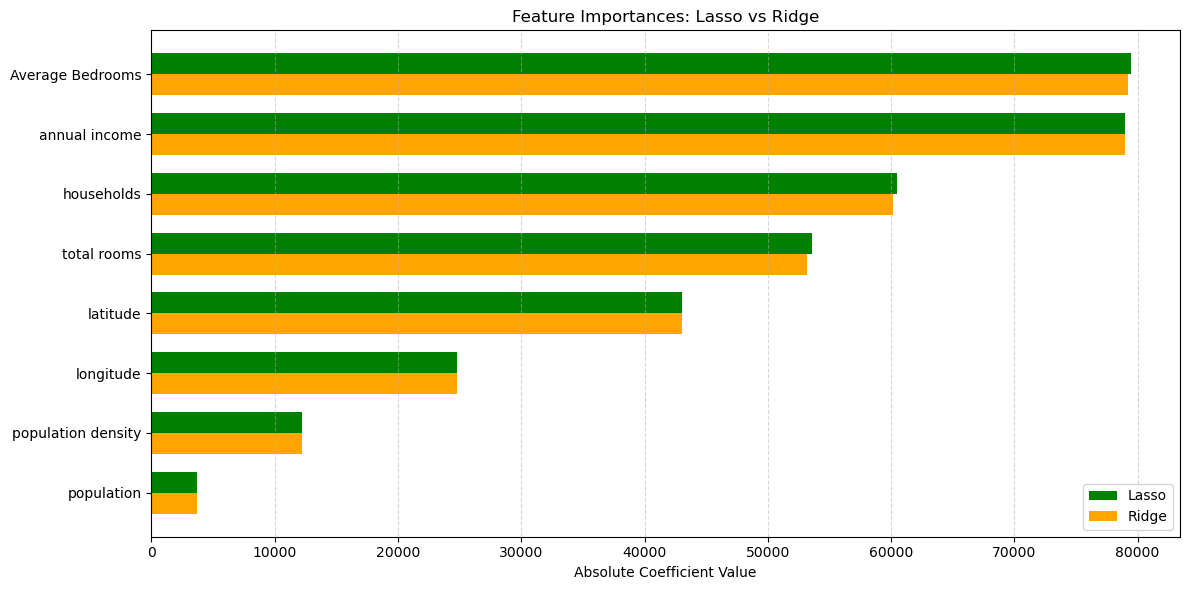

In [27]:
lasso_model = Lasso_piped_new.named_steps['lassocv']
ridge_model = Ridge_piped_new.named_steps['ridgecv']
#Get the feature names
feature_names = Xtrain.columns

#Get coefficients
lasso_coef = np.abs(lasso_model.coef_)
ridge_coef = np.abs(ridge_model.coef_)

#Create DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Lasso': lasso_coef,
    'Ridge': ridge_coef
}).sort_values(by='Lasso', ascending=False)  # sort by one for consistent ordering

#Plot
x = np.arange(len(importance_df))  # Feature positions
width = 0.35  # Width of the bars

plt.figure(figsize=(12, 6))
plt.barh(x - width/2, importance_df['Lasso'], height=width, label='Lasso', color='green')
plt.barh(x + width/2, importance_df['Ridge'], height=width, label='Ridge', color='orange')

plt.yticks(x, importance_df['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importances: Lasso vs Ridge')
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Conclusion: 

## References:

1) Linda Cremonsei, 2025, HousingEngland.csv, Queen Mary University of London
2) Mathew Keep, 2025, Housing market: Economic indicators, House of Commons Library, Available at:https://commonslibrary.parliament.uk/research-briefings/sn02820/#:~:text=Find%20the%20latest%20data%20on%20house%20prices%2C%20mortgage,be%20found%20on%20the%20main%20Economic%20Indicators%20page.

## Word count

In [28]:
import io
import nbformat

filepath ='FinalProject_2025_UKHousing.ipynb'

with io.open(filepath, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

word_instructions = 35
word_count = 0
for cell in nb.cells:
    if cell.cell_type == "markdown":
        word_count += len(cell['source'].replace('#', '').lstrip().split())
print("The total word count is:", word_count - word_instructions)


The total word count is: 279
